# Turn Data into Dashboards with Seaborn & Plotly

## What you'll learn
- Clean messy data using Pandas & NumPy
- Perform basic EDA (Exploratory Data Analysis)
- Build insightful visualizations using Seaborn
- Create interactive dashboards using Plotly

## Scenario

You just joined as a **Data Analyst** at an e-commerce company.

Your manager asks:
> "Can you quickly analyze our sales data and show insights?"

Let us do that step by step

For today's demo,let's use data set of a restaurant. [Data Set Link](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv)

## Setup: Libraries We'll Use

Before we start, let's understand the tools we'll use:

### Libraries

- **Pandas** : For working with data (tables, cleaning, manipulation)
- **NumPy** : For numerical operations (fast calculations)
- **Seaborn** : For beautiful statistical visualizations
- **Matplotlib** : Base library for plotting (Seaborn works on top of it)
- **Plotly** : For interactive charts and dashboards

### Installation

If you're running this on your local machine and don't have these installed, run:

```bash
pip install pandas numpy seaborn matplotlib plotly
```

In Google Colab these are generally installed.

In [13]:
!pip install pandas numpy seaborn matplotlib plotly

Let's try to import all the necessary libraries to see all are imported correctly or not.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set(style="whitegrid")  # Applies a default theme with a white background and grid lines for better visualization

## Step 1: Load the Data

We will use a sample e-commerce dataset.

It contains:
- Order Date
- Region
- Category
- Sales
- Profit

Let us load and inspect it.

In [15]:
# Setting the URL of the data source
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

# Loading the data into a Pandas dataframe (we can also store the data in a csv format on local and give its path)
df = pd.read_csv(url)

# Checking the data to understand how the data looks
df

# We can also use df.head() and df.tail() to get top 5 and last 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Step 2: Understanding the Data

Before cleaning, always ask:

- How many rows are missing?
- What are the missing values?
- What are the various data types?

In [16]:
# To understand more details like null values, mean, average, max, etc. We can use info and describe
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Step 3: Cleaning the Data

Bad data will result in bad insights and the final dashboard will not come out as expected so we should first:

- Handle missing values
- Fix column names
- Create useful features

In [17]:
# Renaming columns for clarity
df.columns = df.columns.str.lower()

# Creating new feature
df['total_bill_per_person'] = df['total_bill'] / df['size']
df['food_bill'] = df['total_bill'] - df['tip']

df.head()

,total_bill,tip,sex,smoker,day,time,size,total_bill_per_person,food_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000,15.98
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667,8.68
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333,17.51
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000,20.37
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500,20.98


## Step 4: Exploring Data with Seaborn

After cleaning and understanding the data, our next step is to understand the data. In this, Seaborn can helps us to:

- Identify trends in our data
- Compare various categories amoung our data
- Spot patterns quickly

**Chart 1: Distribution**

This will help us to answer the question: "Is this evenly distributed or skewed?"

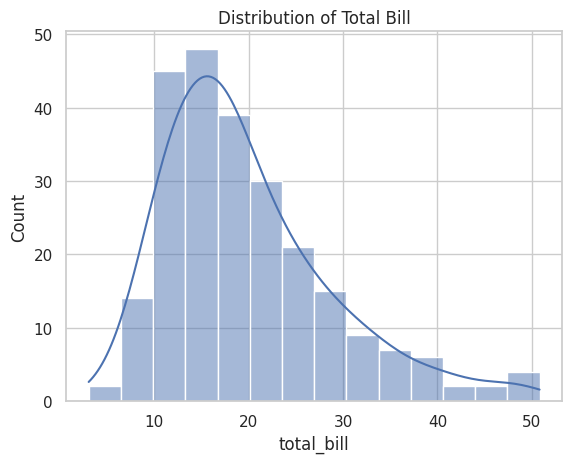

In [18]:
# Creating a new figure (canvas) for the plot
plt.figure()

# Plotting distribution of 'total_bill' using histogram + KDE (smooth curve)
sns.histplot(df['total_bill'], kde=True)

# Adding a title to the plot
plt.title("Distribution of Total Bill")

# Displaying the final plot
plt.show()

**Chart 2: Category Comparison**

This will help us to answer the question: "Which day generates the most revenue?"

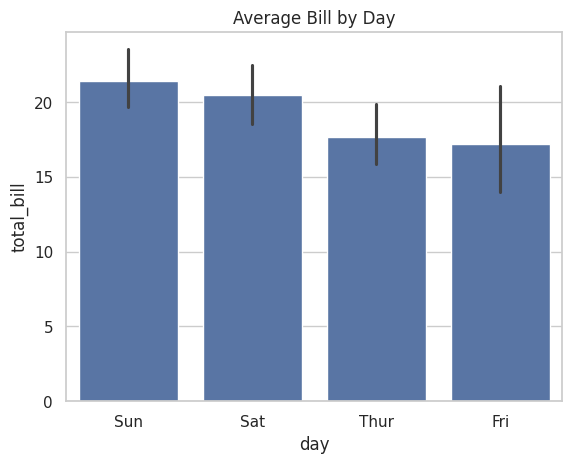

In [19]:
plt.figure()
# Creating a bar chart showing average total bill for each day
sns.barplot(x='day', y='total_bill', data=df)
plt.title("Average Bill by Day")
plt.show()

**Chart 3: Relationship**:

This will help us to find the relationships amount data.

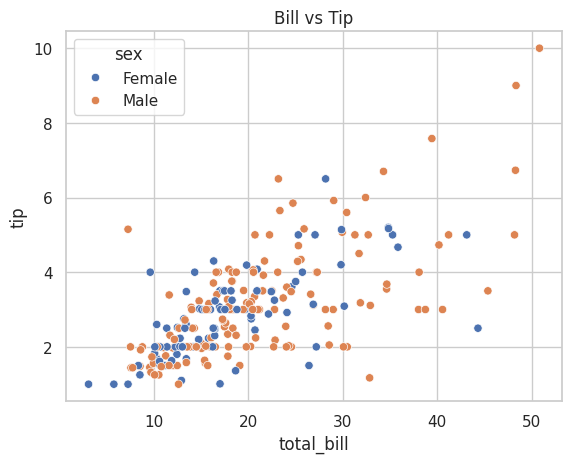

In [20]:
# Creating a new figure (canvas) for the plot
plt.figure()


# Scatter plot:
# X-axis → total_bill (amount spent)
# Y-axis → tip (amount given as tip)
# Each point represents one transaction
# hue='sex' is basically a 3d dimension that adds color to differentiate categories (male vs female), helping compare patterns between groups
sns.scatterplot(x='total_bill', y='tip', hue='sex', data=df)

# Adding a title to the plot
plt.title("Bill vs Tip")

# Displaying the final plot
plt.show()

## Step 5: From Analysis to Actual Communication

Seaborn is great for analysis but what if we want:

- Interactivity?
- Dashboards?
- Business presentations?

For these things, we should create an interractive dashboard with Plotly

## Step 6: Interactive Visuals (Plotly)

### Chart 1: Interactive Scatter

We can hover over points (this is what Stakeholders do to understand the data)

In [21]:
# Creating an interactive scatter plot using Plotly:
# X-axis → total_bill (amount spent)
# Y-axis → tip (amount given as tip)
# color="day" → differentiates data points by day using colors (adds grouping insight)
# Allows interactions like hover, zoom, and filtering
fig = px.scatter(df, x="total_bill", y="tip", color="day",
                 title="Interactive: Bill vs Tip")

# Displaying the interactive plot
fig.show()


### Chart 2: Interactive Bar Chart

In [22]:
# Creating an interactive bar chart using Plotly:
# X-axis → day (categories like Thur, Fri, Sat, Sun)
# Y-axis → total_bill (values for each category)
# color="day" → assigns different colors to each day for better visual distinction
# By default, Plotly aggregates data (usually sum) for each category
fig = px.bar(df, x="day", y="total_bill", color="day",
             title="Total Bill by Day")

# Displaying the interactive bar chart
fig.show()

### Filtered View

In [23]:
# Createing an animated interactive scatter plot:
# X-axis → total_bill (amount spent by customers)
# Y-axis → time (Lunch or Dinner category)
# Each point represents a transaction
# animation_frame="day" → splits the data into frames by day and plays them as an animation
# This shows how the relationship between bill amount and time changes across different days
fig = px.scatter(df, x="total_bill", y="time",
                 animation_frame="day",
                 title="Sales Across Days (Animated)")

# Displaying the animated plot with play controls, hover info, and zoom
fig.show()

## Step 7: Thinking Like a Dashboard Builder

Now since we have built our dashboard, our dashboard should answers:
- What's happening?
- Why is it happening?
- What should we do?

**Tip**: Combine multiple charts to tell a story.

## Step 8: Building a Mini Dashboard

Now let's combine everything into a **single dashboard view**.
A good dashboard:
- Has a clear title
- Shows multiple insights at once
- Helps in decision-making quickly

We'll include:
- Sales distribution
- Sales by day
- Relationship (bill vs tip)
- Category split

Lets build it.

In [24]:
# Using plotly to create multiple plots (subplots) in a single dashboard layout
from plotly.subplots import make_subplots

# graph_object provides low-level control to build custom and detailed plots
import plotly.graph_objects as go

# Createing a grid layout with 2 rows and 2 columns (total 4 plots)
fig = make_subplots(
    rows=2, cols=2,

# Adding title for each subplot in the dashboard
    subplot_titles=(
        "Distribution of Total Bill",
        "Average Bill by Day",
        "Bill vs Tip",
        "Smoker vs Non-Smoker Spending"
    ),

# Defineing the type of each subplot:
    # "xy" → standard plots (scatter, bar, histogram with x-y axes)
    # "domain" → plots like pie charts (no x-y axes, use proportions)
    specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "domain"}]
    ]

)

# Histogram (Distribution)
hist = px.histogram(df, x="total_bill")
for trace in hist.data:
    fig.add_trace(trace, row=1, col=1)

# Bar Chart (Avg Bill by Day)
bar = px.bar(df, x="day", y="total_bill")
for trace in bar.data:
    fig.add_trace(trace, row=1, col=2)

# Scatter Plot (Relationship)
scatter = px.scatter(df, x="total_bill", y="tip", color="sex")
for trace in scatter.data:
    fig.add_trace(trace, row=2, col=1)

# Pie Chart (Category split)
pie = px.pie(df, names="smoker")
for trace in pie.data:
    fig.add_trace(trace, row=2, col=2)

# Updating the layout (THIS MAKES IT LOOK LIKE A DASHBOARD)
fig.update_layout(
    height=800,
    width=1000,
    title_text="Restaurant Analysis Dashboard",
    title_x=0.5
)

fig.show()

## Key Takeaways

- Clean data before analysis
- Use Seaborn for understanding
- Use Plotly for storytelling
- Dashboards = decision tools

## Your Turn

Try:
- Adding new features
- Creating your own charts
- Building a mini dashboard

If you build something cool; share it over social media this will give you reach, confidence and you can learn from other's work and their suggestions.

## Resources

- [GitHub Repo](https://github.com/aadyaasrivastava18/foundations_of_data_visualization)


## Thank You!